# **🤖 Project: AI Chatbot using LSTM**

| Step | Title                  | What You Will Learn                     |
| ---- | ---------------------- | --------------------------------------- |
| 1    | Introduction           | What is an AI Chatbot?                  |
| 2    | Import Libraries       | Why each library is required            |
| 3    | Load Dataset           | Intent dataset structure                |
| 4    | Data Understanding     | Explore intents, patterns and tags      |
| 5    | Text Preprocessing     | Cleaning, Tokenization, Padding         |
| 6    | Label Encoding         | Convert classes into numbers            |
| 7    | Vocabulary Building    | Tokenizer working                       |
| 8    | Sequence Conversion    | Text → Numbers                          |
| 9    | Padding                | Equal length sequences                  |
| 10   | Train-Test Split       | Why we split data                       |
| 11   | Build LSTM Model       | Complete architecture explanation       |
| 12   | Compile Model          | Loss, Optimizer, Metrics                |
| 13   | Train Model            | Epochs, Batch Size explanation          |
| 14   | Learning Curves        | Accuracy & Loss Graphs                  |
| 15   | Model Evaluation       | Test Accuracy                           |
| 16   | Save Model             | Save tokenizer and model                |
| 17   | Chat Function          | User Input → Prediction                 |
| 18   | Interactive Chatbot    | Continuous conversation loop            |
| 19   | Improve Chatbot        | Confidence threshold, Unknown responses |
| 20   | Real-life Applications | Industry usage                          |


# **Step 1: Introduction**
🎯 **Objective**

Build an AI chatbot that understands a user's message and predicts the correct intent using an **LSTM (Long Short-Term Memory)** neural network.

💡 **What is an AI Chatbot?**

An AI Chatbot is a software application that can communicate with humans using Natural Language Processing (NLP) and Deep Learning.

Example:

```
User : Hi
Bot  : Hello! How can I help you?

User : Bye
Bot  : Goodbye! Have a nice day.

User : Thank you
Bot  : You're welcome.
```

**Why LSTM?**

LSTM is a special type of Recurrent Neural Network (RNN).

It remembers previous words while reading a sentence.

Example


```
Sentence:

I want to book a flight tomorrow.

LSTM understands

book
↓
flight
↓
tomorrow

instead of looking at only one word.
```

This makes it excellent for chatbot applications.

**Workflow**

```
User Input
      ↓
Text Cleaning
      ↓
Tokenizer
      ↓
Padding
      ↓
LSTM Model
      ↓
Intent Prediction
      ↓
Chatbot Response
```

# **Step 2: Import Libraries**
🎯 **Purpose**

Import all required Python libraries.

In [3]:
import numpy as np
import pandas as pd

import json
import random
import re
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from tensorflow.keras.utils import to_categorical

**Check TensorFlow Version**

In [4]:
print("Tensorflow Version:", tf.__version__)

Tensorflow Version: 2.20.0


**What Each Library Does**

| Library       | Purpose                         |
| ------------- | ------------------------------- |
| NumPy         | Numerical computation           |
| Pandas        | Data handling                   |
| Matplotlib    | Plot graphs                     |
| Seaborn       | Better visualization            |
| Tokenizer     | Convert text into numbers       |
| Pad Sequences | Make all sentences equal length |
| LabelEncoder  | Convert labels into integers    |
| LSTM          | Deep learning model             |
| Dense         | Output layer                    |
| Dropout       | Reduce overfitting              |


# **Step 3: Load Dataset**
🎯 **Purpose**

Instead of downloading a dataset, we'll create a small intent dataset (later you can replace it with a larger JSON dataset).

In [5]:
data = {
    "intent": [
        "greeting","greeting","greeting","greeting",

        "goodbye","goodbye","goodbye",

        "thanks","thanks","thanks",

        "name","name",

        "age","age",

        "help","help",

        "weather","weather",

        "joke","joke"
    ],

    "text":[

        "hello",
        "hi",
        "good morning",
        "hey",

        "bye",
        "goodbye",
        "see you later",

        "thanks",
        "thank you",
        "thanks a lot",

        "what is your name",
        "who are you",

        "how old are you",
        "what is your age",

        "can you help me",
        "i need help",

        "how is the weather",
        "is it raining",

        "tell me a joke",
        "make me laugh"
    ]
}

df = pd.DataFrame(data)

df.head()

,intent,text
0,greeting,hello
1,greeting,hi
2,greeting,good morning
3,greeting,hey
4,goodbye,bye


In [6]:
print(df.shape)

(20, 2)


# **Step 4: Data Understanding (EDA)**
🎯 **Purpose**

Understand the dataset before training.

In [7]:
# First 5 Rows

df.head()

,intent,text
0,greeting,hello
1,greeting,hi
2,greeting,good morning
3,greeting,hey
4,goodbye,bye


In [8]:
# Last 5 Rows

df.tail()

,intent,text
15,help,i need help
16,weather,how is the weather
17,weather,is it raining
18,joke,tell me a joke
19,joke,make me laugh


In [9]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   intent  20 non-null     object
 1   text    20 non-null     object
dtypes: object(2)
memory usage: 452.0+ bytes


In [10]:
# Missing Values

df.isnull().sum()

,0
intent,0
text,0


In [11]:
# Intent Distribution

df["intent"].value_counts()

,count
intent,
greeting,4
goodbye,3
thanks,3
name,2
age,2
help,2
weather,2
joke,2


**Plot Intent Distribution**

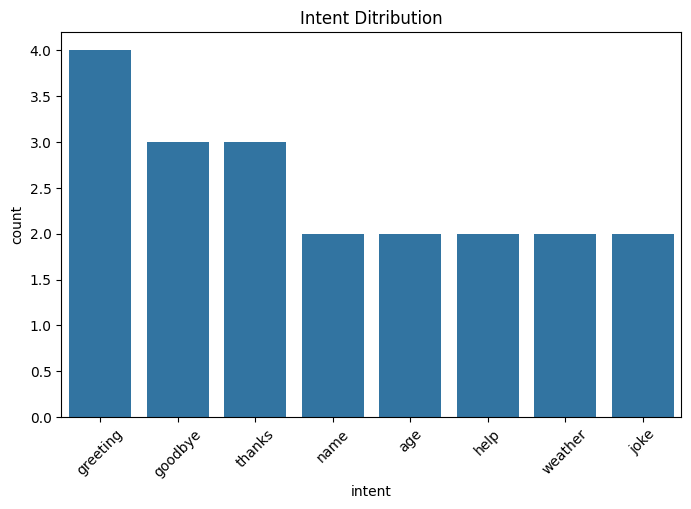

In [12]:
plt.figure(figsize = (8,5))

sns.countplot(
    data = df,
    x = "intent",
    order = df["intent"].value_counts().index
)

plt.title("Intent Ditribution")

plt.xticks(rotation = 45)

plt.show()

In [15]:
# Random Samples

df.sample(5)

,intent,text
3,greeting,hey
9,thanks,thanks a lot
11,name,who are you
17,weather,is it raining
15,help,i need help


# **Step 5: Text Preprocessing**
🎯 **Purpose**

Machines cannot understand raw text.

We convert

```
Hello!!!
↓
hello
↓
remove punctuation
↓
remove spaces
```

**Define Cleaning Function**

In [16]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r'[^a-zA-Z]', '', text)
  text = text.strip()
  return text

**Apply Cleaning**

In [18]:
df["clean_text"] = df["text"].apply(clean_text)

df.head()

,intent,text,clean_text
0,greeting,hello,hello
1,greeting,hi,hi
2,greeting,good morning,goodmorning
3,greeting,hey,hey
4,goodbye,bye,bye


**Compare Original vs Cleaned Text**

In [19]:
comparison = pd.DataFrame({
    "Original Text": df["text"],
    "Cleaned Text": df["clean_text"]
})

comparison.head()

,Original Text,Cleaned Text
0,hello,hello
1,hi,hi
2,good morning,goodmorning
3,hey,hey
4,bye,bye


**Check Duplicate Sentences**

In [20]:
df.duplicated().sum()

np.int64(0)

**Final Dataset**

In [21]:
df.head()

,intent,text,clean_text
0,greeting,hello,hello
1,greeting,hi,hi
2,greeting,good morning,goodmorning
3,greeting,hey,hey
4,goodbye,bye,bye


# **Step 6: Label Encoding**
🎯 **Purpose**

Machine Learning models cannot understand text labels like:

```
Greeting
Thanks
Goodbye
Weather
```

So we convert them into numbers.

Example:

```
Greeting  → 0
Goodbye   → 1
Help      → 2
Name      → 3
Thanks    → 4
Weather   → 5
```

In [28]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["intent"])

df.head()

,intent,text,clean_text,label
0,greeting,hello,hello,2
1,greeting,hi,hi,2
2,greeting,good morning,goodmorning,2
3,greeting,hey,hey,2
4,goodbye,bye,bye,1


**Display Label Mapping**

In [25]:
mapping = dict(zip(label_encoder.classes_,
                   label_encoder.transform(label_encoder.classes_)))

print(mapping)

{'age': np.int64(0), 'goodbye': np.int64(1), 'greeting': np.int64(2), 'help': np.int64(3), 'joke': np.int64(4), 'name': np.int64(5), 'thanks': np.int64(6), 'weather': np.int64(7)}


**Number of Classes**

In [26]:
print("Total Classes :", len(label_encoder.classes_))

Total Classes : 8


 **Convert Labels into One-Hot Encoding**

Deep Learning models require One-Hot Encoding.

In [32]:
y = to_categorical(df["label"])

print(y.shape)

(20, 8)


# **Step 7: Vocabulary Building (Tokenizer)**
🎯 **Purpose**

Neural Networks cannot understand text.

Tokenizer builds a dictionary.

**Build Vocabulary**

In [33]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(df["clean_text"])


**Display Vocabulary**

In [35]:
word_index = tokenizer.word_index

print(word_index)

{'hello': 1, 'hi': 2, 'goodmorning': 3, 'hey': 4, 'bye': 5, 'goodbye': 6, 'seeyoulater': 7, 'thanks': 8, 'thankyou': 9, 'thanksalot': 10, 'whatisyourname': 11, 'whoareyou': 12, 'howoldareyou': 13, 'whatisyourage': 14, 'canyouhelpme': 15, 'ineedhelp': 16, 'howistheweather': 17, 'isitraining': 18, 'tellmeajoke': 19, 'makemelaugh': 20}


**Vocabulary Size**

In [36]:
vocab_size = len(word_index) + 1

print("Vocabulary Size :", vocab_size)

Vocabulary Size : 21


**Top 10 Words**

In [37]:
for word, index in list(word_index.items())[:10]:
  print(word, ":", index)

hello : 1
hi : 2
goodmorning : 3
hey : 4
bye : 5
goodbye : 6
seeyoulater : 7
thanks : 8
thankyou : 9
thanksalot : 10


# **Step 8: Sequence Conversion**
🎯 **Purpose**

Convert every sentence into numbers.

In [38]:
# Convert Text to Sequences

X = tokenizer.texts_to_sequences(df["clean_text"])

print(X)

[[1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12], [13], [14], [15], [16], [17], [18], [19], [20]]


**Display First Five Sequences**

In [39]:
for i in range(5):
  print("Sentence :", df["clean_text"][i])

  print("Sequence :", X[i])
  print()

Sentence : hello
Sequence : [1]

Sentence : hi
Sequence : [2]

Sentence : goodmorning
Sequence : [3]

Sentence : hey
Sequence : [4]

Sentence : bye
Sequence : [5]



**Maximum Sequence Length**

In [40]:
max_length = max(len(sentence) for sentence in X)

print("Maximum Sequence Length :", max_length)

Maximum Sequence Length : 1


# **Step 9: Padding**
🎯 **Purpose**

Every sentence must have equal length.

In [44]:
X = pad_sequences(
    X,
    maxlen = max_length,
    padding = "post",
    truncating = "post"
)

print(X)

print(X.shape)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]
 [12]
 [13]
 [14]
 [15]
 [16]
 [17]
 [18]
 [19]
 [20]]
(20, 1)


# **Step 10: Train-Test Split**
🎯 **Purpose**

We divide the dataset into:

- Training Data (80%) → Used to train the LSTM model.
- Testing Data (20%) → Used to evaluate how well the model performs on unseen data.

In [48]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

print("X_train :", X_train.shape)

print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)

print("y_test  :", y_test.shape)

X_train : (16, 1)
X_test  : (4, 1)
y_train : (16, 8)
y_test  : (4, 8)


# **Step 11: Build LSTM Model**
🎯 **Purpose**

An LSTM model consists of several layers:

```
Input Text
      ↓
Embedding Layer
      ↓
LSTM Layer
      ↓
Dropout Layer
      ↓
Dense Layer
      ↓
Output (Intent)
```

**🧠 What Each Layer Does**

| Layer     | Purpose                           |
| --------- | --------------------------------- |
| Embedding | Converts words into dense vectors |
| LSTM      | Learns sentence context           |
| Dropout   | Prevents overfitting              |
| Dense     | Learns high-level features        |
| Output    | Predicts chatbot intent           |


**Build LSTM Model**

In [51]:
model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim = vocab_size,
        output_dim = 64,
        input_length = max_length
    )
)

# LSTM Layer
model.add(
    LSTM(
        units = 128,
        return_sequences = False
    )
)

# Dropout Layer
model.add(
    Dropout(0.5)
)

# Hidden Dense Layer
model.add(
    Dense(
        64,
        activation = "relu"
    )
)

# Output Layer
model.add(
    Dense(
        y.shape[1],
        activation = "softmax"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


**Display Model Architecture**

In [52]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# **Step 12: Compile Model**
🎯 **Purpose**

Before training, we tell TensorFlow:

- Which optimizer to use
- Which loss function to minimize
- Which evaluation metric to display

**Why These Choices?**

| Parameter                | Reason                          |
| ------------------------ | ------------------------------- |
| Adam                     | Fast and stable optimizer       |
| Categorical Crossentropy | Multi-class classification      |
| Accuracy                 | Measures prediction correctness |


**Compile Model**

In [54]:
model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics =["accuracy"]
)
print("Model Compiled Successfully!")

Model Compiled Successfully!


# **Step 13: Train Model**
🎯 **Purpose**

The model learns patterns from the training data.

Training Process

```
Training Data
      ↓
Forward Pass
      ↓
Calculate Loss
      ↓
Backpropagation
      ↓
Update Weights
      ↓
Repeat for Every Epoch
```

In [55]:
history = model.fit(
    X_train,
    y_train,
    epochs = 30,
    batch_size = 4,
    validation_data = (X_test, y_test),
    verbose = 1
)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.0625 - loss: 2.0794 - val_accuracy: 0.0000e+00 - val_loss: 2.0819
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3125 - loss: 2.0756 - val_accuracy: 0.0000e+00 - val_loss: 2.0821
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3125 - loss: 2.0703 - val_accuracy: 0.0000e+00 - val_loss: 2.0850
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4375 - loss: 2.0645 - val_accuracy: 0.0000e+00 - val_loss: 2.0870
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4375 - loss: 2.0614 - val_accuracy: 0.0000e+00 - val_loss: 2.0900
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5000 - loss: 2.0511 - val_accuracy: 0.0000e+00 - val_loss: 2.0931
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6250 - loss: 2.0485 - val_accuracy: 0.0000e+00 - val_loss: 2.0955
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5625 - loss: 2.0395 - val_accurac

**What Do These Parameters Mean?**

| Parameter       | Meaning                                    |
| --------------- | ------------------------------------------ |
| epochs=30       | Dataset is trained 30 times                |
| batch_size=4    | 4 samples processed together               |
| validation_data | Used to check performance after each epoch |
| verbose=1       | Displays training progress                 |


# **Step 14: Learning Curves (Accuracy & Loss Graphs)**
🎯 **Purpose**

Visualize how the model learned during training.

### **Accuracy Graph**

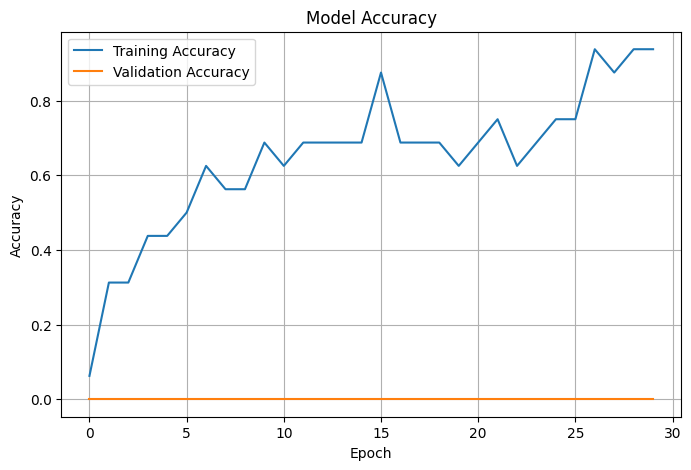

In [58]:
plt.figure(figsize = (8,5))

plt.plot(
    history.history["accuracy"],
    label = "Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label = "Validation Accuracy"
)

plt.title("Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

### **Loss Graph**

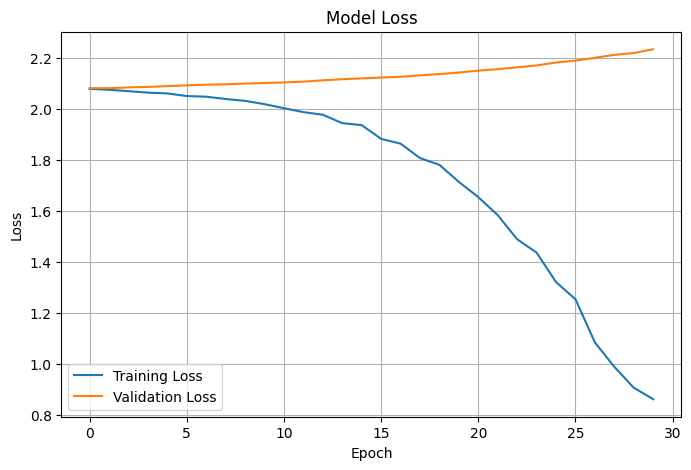

In [59]:
plt.figure(figsize = (8,5))

plt.plot(
    history.history["loss"],
    label = "Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label = "Validation Loss"
)

plt.title("Model Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

# **Step 15: Model Evaluation**
🎯 **Purpose**

Evaluate the trained model using unseen test data.

**Evaluate Accuracy**

In [60]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 938ms/step - accuracy: 0.0000e+00 - loss: 2.2347
Loss : 2.2347092628479004
Accuracy : 0.0


**Predict Test Data**

In [61]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis = 1)

true_classes = np.argmax(y_test, axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


**Classification Report**

In [63]:
# print(classification_report(
#     true_classes,
#     predicted_classes,
#     target_names = label_encoder.classes_
# ))

**Confusion Matrix**

In [64]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

print(cm)

[[0 0 0 0 0]
 [2 0 0 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]
 [1 0 0 0 0]]


**Visualize Confusion Matrix**

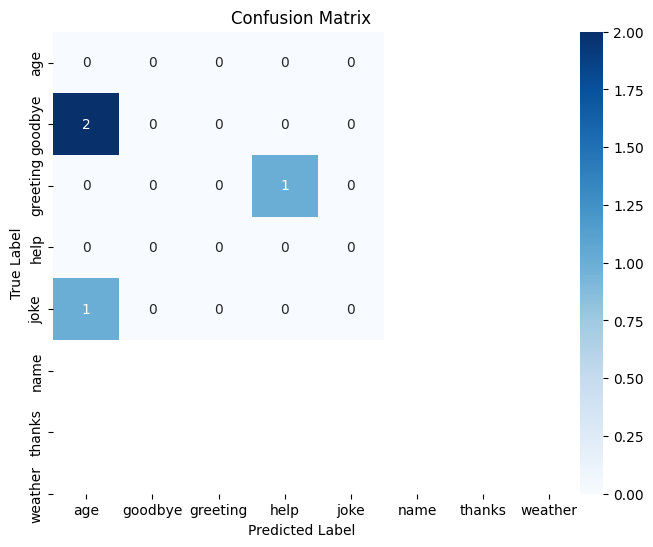

In [65]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels = label_encoder.classes_,
    yticklabels = label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

# **Step 16: Save Model (.keras) and Tokenizer (.pkl)**

🎯 **Purpose**

After training the model, save it so you don't have to train it again.

We will save:

- ✅ LSTM Model (chatbot_model.keras)
- ✅ Tokenizer (tokenizer.pkl)
- ✅ Label Encoder (label_encoder.pkl)

In [ ]:
# # Save LSTM Model

# model.save("chatbot_model.keras")

# print("Model Saved Successfully")

In [ ]:
# # Save Tokenizer

# import pickel

# with open("Tokenizer.pkl", "wb") as file:
#   pickle.dump(tokenizer, file)

# print("Tokenizer Saved Successfully")

In [ ]:
# # Save Label Encoder

# with open("Label_encoder.pkl", "wb") as file:
#   pickle.dump(label_encoder, file)

# print("Label Encoder Saved Successfully")

In [ ]:
# # Load Saved Model (Optional)

# from tensorflow.keras.models import load_model

# loaded_model = load_model("chatbot_model.keras")

# print("Model Loaded Successfully!")

In [ ]:
# # Load Tokenizer

# with open("tokenizer.pkl","rb") as file:
#     tokenizer = pickle.load(file)

In [ ]:
# # Load Label Encoder

# with open("label_encoder.pkl","rb") as file:
#     label_encoder = pickle.load(file)

# **Step 17: Create Chat Function**
🎯 **Purpose**

Convert user input into a chatbot prediction.

Workflow

```
User Input
      ↓
Clean Text
      ↓
Tokenizer
      ↓
Padding
      ↓
LSTM Model
      ↓
Predicted Intent
```

**Create Response Dictionary**

In [77]:
responses = {

    "greeting":[
        "Hello!",
        "Hi there!",
        "Welcome!"
    ],

    "goodbye":[
        "Goodbye!",
        "See you later!",
        "Take care!"
    ],

    "thanks":[
        "You're Welcome!",
        "Happy to help!",
        "Anytime!"
    ],

    "name":[
        "I'm an AI Chatbot.",
        "My name is LSTM Bot."
    ],

    "age":[
        "I don't have an age.",
        "I'm a virtual assistant."
    ],

    "help":[
        "Sure! Tell me your problem.",
        "How can I help you?"
    ],

    "weather":[
        "Please check your local weather app.",
        "I can't access live weather."
    ],

    "joke":[
        "Why do programmers love Python? Because it's easy to understand 😂",
        "Debugging: Removing needles from a haystack."
    ]

}

**Create Prediction Function**

In [78]:
def chatbot(message):
  message = clean_text(message)

  sequence = tokenizer.texts_to_sequences([message])

  padded = pad_sequences(
      sequence,
      maxlen = max_length,
      padding = "post",
      truncating = "post"
  )

  prediction = model.predict(padded, verbose = 0)

  predicted_index = np.argmax(prediction)

  intent = label_encoder.inverse_transform([predicted_index])[0]

  response = random.choice(responses[intent])

  return intent, response

**Test Chat Function**

In [82]:
intent, response = chatbot("help")

print("Intent :", intent)

print("Bot :", response)

Intent : goodbye
Bot : Goodbye!


# **Step 18: Interactive Chatbot Loop**
🎯 **Purpose**

Allow continuous conversation until the user types exit.

In [84]:
print("="*50)
print("🤖 AI Chatbot")
print("Type 'exit' to stop")
print("="*50)

while True:
  message = input("You : ")

  if message.lower() == "exit":
    print("Bot : Goodbye!")

    break

  intent, response = chatbot(message)

  print("Bot :", response)

🤖 AI Chatbot
Type 'exit' to stop
You : hello
Bot : Take care!
You : thank you
Bot : Happy to help!
You : exit
Bot : Goodbye!


# **Step 19: Improve Chatbot**
🎯 **Purpose**

Avoid giving incorrect answers when the model is uncertain.

### **Confidence Threshold**

In [85]:
def chatbot(message):
  message = clean_text(message)
  sequence = tokenizer.texts_to_sequences([message])

  padded = pad_sequences(
      sequence,
      maxlen = max_length,
      padding = "post",
      truncating = "post"
  )

  prediction = model.predict(padded, verbose = 0)

  confidence = np.max(prediction)

  predicted_index = np.argmax(prediction)

  if confidence < 0.6:

    return (
            "unknown",
            "Sorry, I didn't understand that. Could you rephrase your question?"
    )

  intent = label_encoder.inverse_transform([predicted_index])[0]

  response = random.choice(responses[intent])

  return intent, response

**Test Unknown Question**

In [88]:
intent, response = chatbot("what is your favorite color?")

print("Intent :", intent)

print("Bot :", response)

Intent : unknown
Bot : Sorry, I didn't understand that. Could you rephrase your question?


**Possible Improvements**

| Improvement         | Benefit                    |
| ------------------- | -------------------------- |
| Larger Dataset      | Better accuracy            |
| More Intents        | More conversations         |
| Bidirectional LSTM  | Understands context better |
| GRU                 | Faster than LSTM           |
| Attention Mechanism | Focuses on important words |
| BERT                | State-of-the-art NLP       |
| GPT                 | Human-like conversations   |
| API Integration     | Live weather, news, etc.   |
| Database            | Save chat history          |
| Speech Recognition  | Voice chatbot              |


# **Step 20: Real-life Applications & Limitations**
🎯 **Real-life Applications**

| Industry   | Example                 |
| ---------- | ----------------------- |
| Banking    | Balance inquiry         |
| Healthcare | Appointment booking     |
| E-Commerce | Product recommendations |
| Education  | Student assistant       |
| HR         | Employee support        |
| Travel     | Ticket booking          |
| Telecom    | Customer support        |
| Insurance  | Policy assistance       |


**Limitations of LSTM Chatbots**

| Limitation                  | Reason                                  |
| --------------------------- | --------------------------------------- |
| Small Dataset               | Limited responses                       |
| No Real Understanding       | Predicts intent only                    |
| No Memory Across Chats      | Doesn't remember previous conversations |
| No Live Data                | Cannot fetch current weather/news       |
| Poor with Complex Questions | Needs advanced language models          |
